<a href="https://colab.research.google.com/github/madhav97-ux/Health-Data-Science/blob/main/flair_covid_sentiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os

OUTPUT_DIR = '/content/drive/MyDrive/flair experiments'

# Create the directory if it doesn't exist
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Output directory created at: {OUTPUT_DIR}")

Output directory created at: /content/drive/MyDrive/flair experiments


# 🦁 COVID-19 Tweet Sentiment Analysis with FlairNLP

**Dataset:** [COVID-19 NLP Text Classification — Kaggle](https://www.kaggle.com/datasets/datatattle/covid-19-nlp-text-classification)  
**Primary library:** [FlairNLP](https://github.com/flairNLP/flair) — as requested by supervisor

---

## What this notebook does — in plain English

We take **44,955 COVID tweets** that humans have labelled with a sentiment
(e.g. *Positive*, *Negative*, *Neutral*) and train a computer to
**automatically predict the sentiment of new tweets it has never seen before**.

That is the task of **text classification** — one of the most common NLP problems.

```
Tweet text  ──→  [FlairNLP model]  ──→  Sentiment label

"I love this vaccine!"     ──→   POSITIVE
"This pandemic is awful"   ──→   NEGATIVE
"Cases rising again today" ──→   NEUTRAL
```

---

## What we build — step by step

| Step | What happens |
|---|---|
| 1 | Install libraries & download dataset |
| 2 | Load the CSV files and explore the data |
| 3 | Clean the raw tweets (9 preprocessing steps) |
| 4 | Encode text labels into numbers |
| 5 | Write data into the format Flair expects |
| 6 | **Approach A** — Use a ready-made Flair model (no training needed) |
| 7 | **Approach B** — Fine-tune Flair with GloVe word embeddings |
| 8 | **Approach C** — Fine-tune Flair with its own character-level embeddings |
| 9 | Evaluate all models with 9 metrics and visualise results |

---

**How to run on Google Colab:**  
Runtime → Change runtime type → **T4 GPU** → Save → then Run All (Ctrl+F9)

---
## 🐍 Step 0 — Virtual Environment Setup (local only — skip on Colab)

A **virtual environment** is an isolated Python installation just for this project.
Think of it as a clean room: whatever you install here doesn't affect the rest of your computer,
and no other project's libraries can interfere with yours.

**Why it matters:** Without it, installing different versions of libraries for different
projects causes conflicts. Your supervisor flagged this explicitly — it is standard
professional practice.

```bash
# Open your terminal, navigate to your project folder, then:

# 1. Create the virtual environment
#    This makes a folder called 'sentiment_env' with its own Python
python -m venv sentiment_env

# 2. Activate it
source sentiment_env/bin/activate       # Mac / Linux
sentiment_env\Scripts\activate          # Windows

# You will see (sentiment_env) at the start of your terminal prompt — that means it worked.

# 3. Install everything inside the environment
pip install flair kaggle nltk emoji contractions pandas numpy matplotlib seaborn tqdm

# 4. When you're done working, deactivate
deactivate
```

**On Colab:** The Colab session is already isolated — skip straight to the pip install cell below.

---
## 📦 Step 1 — Install Libraries

Here is what each library does and why we need it:

| Library | Purpose |
|---|---|
| `flair` | The main NLP library — loads embeddings, trains classifiers, handles text |
| `kaggle` | Command-line tool to download datasets directly from Kaggle |
| `nltk` | Natural Language Toolkit — gives us tokenisers, stopword lists, lemmatisers |
| `emoji` | Converts emoji characters (😡) into readable text ("pouting face") |
| `contractions` | Expands short forms: "can't" → "cannot", "I'm" → "I am" |
| `pandas` | Loads and manipulates our CSV files as tables (DataFrames) |
| `numpy` | Numerical operations — arrays, random shuffles, maths |
| `matplotlib` / `seaborn` | Plotting charts and graphs |
| `tqdm` | Shows a progress bar when processing thousands of tweets |

In [12]:
# The ! at the start means: run this as a terminal command, not as Python.
# --quiet suppresses the installation logs so the output stays readable.

!pip install flair==0.15.1 --quiet       # FlairNLP — primary library
!pip install kaggle --quiet              # Kaggle dataset downloader
!pip install emoji==2.12.1 --quiet       # emoji to text
!pip install contractions --quiet        # expand contractions

# NLTK (Natural Language Toolkit) needs separate data downloads
# These are model files used during preprocessing:
import nltk
nltk.download('punkt',       quiet=True)   # punkt = sentence/word tokeniser model
nltk.download('punkt_tab',   quiet=True)   # updated punkt data
nltk.download('stopwords',   quiet=True)   # list of English stopwords ('the','a','is'...)
nltk.download('wordnet',     quiet=True)   # WordNet = English word database for lemmatisation

print("All libraries installed successfully.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 25.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 72.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.1/203.1 kB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 77.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 49.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [13]:
!pip install flair[word-embeddings] --quiet
print("Installed gensim for word embeddings.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 52.4 MB/s eta 0:00:00
Installed gensim for word embeddings.


---
## 📊 Step 3 — Load the Data and Explore It

Before doing anything with data you should always look at it first.
This is called **Exploratory Data Analysis (EDA)**.

We want to know:
- What columns exist?
- What do the raw tweets look like?
- How many tweets are in each sentiment class? (class distribution)

The answers to these questions determine every design decision we make later.

In [14]:
import pandas as pd        # pd is the standard alias for pandas
import numpy as np         # np is the standard alias for numpy
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')   # suppress minor warnings that clutter output

# ── Load CSV files ────────────────────────────────────────────────────────────
# pd.read_csv() reads a CSV file into a DataFrame (a table)
# encoding='latin-1' is needed because the CSV file uses the Latin-1 character
#   encoding (not UTF-8). Without this, pandas throws an error on special characters.
# We try two possible file locations because Kaggle sometimes unzips into a subfolder.
try:
    train_df = pd.read_csv('Corona_NLP_train.csv', encoding='latin-1')
    test_df  = pd.read_csv('Corona_NLP_test.csv',  encoding='latin-1')
except FileNotFoundError:
    train_df = pd.read_csv('covid-19-nlp-text-classification/Corona_NLP_train.csv', encoding='latin-1')
    test_df  = pd.read_csv('covid-19-nlp-text-classification/Corona_NLP_test.csv',  encoding='latin-1')

# ── Keep only the columns we need ────────────────────────────────────────────
# The CSV has columns: UserName, ScreenName, Location, TweetAt, OriginalTweet, Sentiment
# We only need the tweet text and its label.
# dropna() removes any rows where either column has a missing value (NaN)
# reset_index(drop=True) resets row numbers to 0,1,2,... after dropping rows
train_df = train_df[['OriginalTweet', 'Sentiment']].dropna().reset_index(drop=True)
test_df  = test_df[['OriginalTweet', 'Sentiment']].dropna().reset_index(drop=True)

print(f"Train set: {len(train_df):,} tweets")
print(f"Test set:  {len(test_df):,} tweets")
print()

# Show the first 3 rows so we can see what a raw tweet looks like
train_df.head(3)

Train set: 41,157 tweets
Test set:  3,798 tweets



,OriginalTweet,Sentiment
0,@MeNyrbie @Phil_Gahan @Chrisitv https://t.co/i...,Neutral
1,advice Talk to your neighbours family to excha...,Positive
2,Coronavirus Australia: Woolworths to give elde...,Positive


=== Sentiment distribution in TRAINING set ===
Sentiment
Positive              11422
Negative               9917
Neutral                7713
Extremely Positive     6624
Extremely Negative     5481
Name: count, dtype: int64



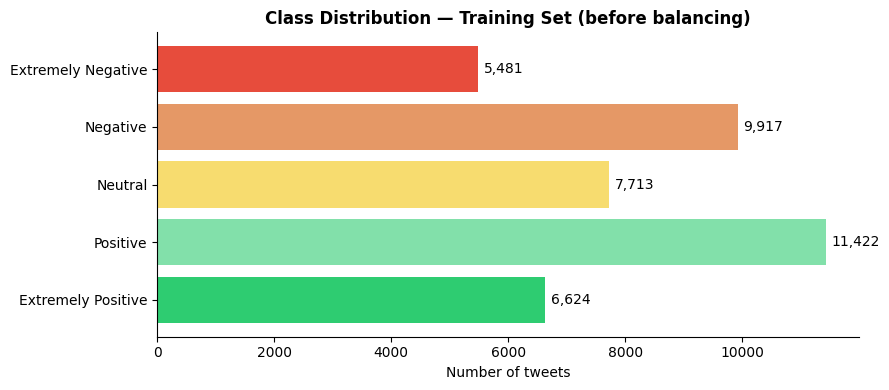

Notice: 'Positive' has 2.5x more examples than 'Extremely Negative'.
This is class imbalance — we fix it with oversampling in Step 5.


In [15]:
# ── Class distribution ────────────────────────────────────────────────────────
# value_counts() counts how many rows have each unique Sentiment value
print("=== Sentiment distribution in TRAINING set ===")
train_counts = train_df['Sentiment'].value_counts()
print(train_counts)
print()

# ── Plot the distribution ─────────────────────────────────────────────────────
# This bar chart reveals the CLASS IMBALANCE problem:
# some sentiments have many more examples than others.
# A model that just always predicts the most common class would look
# deceptively accurate — we need to address this.

order = ['Extremely Positive', 'Positive', 'Neutral', 'Negative', 'Extremely Negative']
colours = ['#2ecc71', '#82e0aa', '#f7dc6f', '#e59866', '#e74c3c']

fig, ax = plt.subplots(figsize=(9, 4))
# We use horizontal bars (barh) because the class names are long
ax.barh(
    [o for o in order],              # y-axis: the class names
    [train_counts[o] for o in order], # x-axis: the counts
    color=colours
)

# Add count labels at the end of each bar
for i, (o, c) in enumerate(zip(order, [train_counts[o] for o in order])):
    ax.text(c + 100, i, f'{c:,}', va='center', fontsize=10)

ax.set_xlabel('Number of tweets')
ax.set_title('Class Distribution — Training Set (before balancing)', fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'class_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

print("Notice: 'Positive' has 2.5x more examples than 'Extremely Negative'.")
print("This is class imbalance — we fix it with oversampling in Step 5.")

---
## 🧹 Step 4 — Text Preprocessing (9 Steps)

A raw tweet looks like this:
```
"@WHO I can't believe #COVID19 is real!! 😡 Check http://t.co/abc #pandemic"
```

A model cannot learn meaningful patterns from this. It needs clean, consistent text.
We apply 9 sequential steps to fix specific problems:

| Step | Problem fixed | Example |
|---|---|---|
| 1. Unicode normalisation | Removes accented/special characters | `café` → `cafe` |
| 2. Contraction expansion | Prevents split meanings | `can't` → `cannot` |
| 3. Emoji → text | Preserves sentiment in emojis | `😡` → `pouting face` |
| 4. Lowercase | Treats `COVID` and `covid` as the same | `COVID` → `covid` |
| 5. Remove noise | URLs/mentions/hashtags carry no sentiment | `@WHO`, `http://...` → removed |
| 6. Tokenise | Splits string into individual word tokens | `"hello world"` → `['hello', 'world']` |
| 7. Remove stopwords | Removes meaningless filler words | `['the', 'not', 'bad']` → `['not', 'bad']` |
| 8. Lemmatise | Reduces words to their base form | `running` → `run`, `better` → `good` |
| 9. Rejoin & clean | Puts tokens back into a string | `['cannot', 'believe']` → `"cannot believe"` |

### ⚠️ Critical: Why we KEEP negations in step 7

Standard stopword removal deletes words like **not, no, never, cannot**.
But for sentiment analysis this is **catastrophically wrong**:
- `"not good"` means the opposite of `"good"`
- Deleting `"not"` would turn a negative tweet into a positive one

So we explicitly **remove negations from the stopword list** before applying it.

In [16]:
import re                              # re = regular expressions — pattern matching in strings
import unicodedata                     # handles character encoding normalisation
import contractions                    # expands contractions
import emoji                           # emoji to text conversion
from nltk.tokenize import word_tokenize  # splits a string into word tokens
from nltk.corpus import stopwords       # the English stopwords list
from nltk.stem import WordNetLemmatizer # lemmatiser (uses WordNet dictionary)
from tqdm.auto import tqdm             # progress bar for long loops
tqdm.pandas()                          # enables df.progress_apply() with a progress bar

# ── Setup objects that we reuse on every tweet ────────────────────────────────

# WordNetLemmatizer looks up the base form of words in the WordNet dictionary
lemmatizer = WordNetLemmatizer()

# Get the English stopwords list — 179 common words like 'the', 'a', 'is', 'in'
STOP_WORDS = set(stopwords.words('english'))   # use a set for O(1) lookup speed

# These are the negation words we MUST keep — removing them flips sentiment
NEGATIONS = {
    'not', 'no', 'never', 'nor', 'neither', "n't", 'cannot',
    "wasn't", "isn't", "aren't", "won't", "don't", "didn't",
    "doesn't", "hadn't", "haven't", "shouldn't", "wouldn't", "couldn't"
}

# -= means: remove NEGATIONS from STOP_WORDS
# After this, the stopword list no longer contains any negation words
STOP_WORDS -= NEGATIONS


def preprocess_tweet(text: str) -> str:
    """
    Clean a single raw tweet through all 9 preprocessing steps.
    Input:  a raw tweet string
    Output: a clean string ready for a model
    """

    # ── Step 1: Unicode normalisation ────────────────────────────────────────
    # str(text) converts any non-string input to string first (safety)
    # normalize('NFKD', ...) decomposes characters:
    #   é  becomes  e + combining accent mark
    # encode('ascii', 'ignore') keeps only ASCII characters, drops everything else
    # decode('utf-8') converts the resulting bytes back to a Python string
    text = unicodedata.normalize('NFKD', str(text))
    text = text.encode('ascii', 'ignore').decode('utf-8')

    # ── Step 2: Expand contractions ──────────────────────────────────────────
    # contractions.fix() uses a lookup table of ~200+ English contractions
    # This MUST happen before lowercasing, because some lookups are case-sensitive
    text = contractions.fix(text)

    # ── Step 3: Emoji → text ──────────────────────────────────────────────────
    # emoji.demojize() replaces emoji characters with their official names
    # delimiters=(' ', ' ') puts spaces around the name so it blends with words
    # Example: 😡 → ' pouting face '
    text = emoji.demojize(text, delimiters=(' ', ' '))

    # ── Step 4: Lowercase ─────────────────────────────────────────────────────
    # .lower() makes the string entirely lowercase
    # Now 'COVID', 'Covid', 'covid' all become 'covid' — treated as one word
    text = text.lower()

    # ── Step 5: Remove URLs, mentions, hashtag symbols ────────────────────────
    # re.sub(pattern, replacement, string) replaces matches of 'pattern' with 'replacement'
    # \S+ means: one or more non-whitespace characters
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)  # remove URLs
    text = re.sub(r'@\w+', '', text)                       # remove @mentions
    text = re.sub(r'#', '', text)                          # remove # but keep the word
    text = re.sub(r'\brt\b', '', text)                     # remove 'rt' (retweet marker)

    # ── Step 6: Tokenise ──────────────────────────────────────────────────────
    # word_tokenize() splits the string into a list of individual word tokens
    # It handles punctuation intelligently, e.g. "don't" → ['do', "n't"]
    tokens = word_tokenize(text)

    # ── Step 7: Remove stopwords ──────────────────────────────────────────────
    # We keep a token only if ALL three conditions are true:
    #   t not in STOP_WORDS  →  it's not a filler word (but we kept negations!)
    #   len(t) > 1           →  it's not a single character like '?' or 'a'
    #   t.isalpha()          →  it contains only letters (drops punctuation/numbers)
    tokens = [
        t for t in tokens
        if t not in STOP_WORDS
        and len(t) > 1
        and t.isalpha()
    ]

    # ── Step 8: Lemmatise ─────────────────────────────────────────────────────
    # Lemmatisation reduces a word to its dictionary/base form:
    #   'running' → 'run'   (as a verb, pos='v')
    #   'dogs'    → 'dog'   (as a noun, pos='n')
    # We do two passes — first as verbs, then the result as nouns
    tokens = [lemmatizer.lemmatize(t, pos='v') for t in tokens]  # verb pass
    tokens = [lemmatizer.lemmatize(t, pos='n') for t in tokens]  # noun pass

    # ── Step 9: Rejoin into a string and clean whitespace ─────────────────────
    # ' '.join(tokens) puts the list back into a single space-separated string
    # re.sub(r'\s+', ' ', ...) collapses multiple spaces into one
    # .strip() removes leading/trailing whitespace
    text = ' '.join(tokens)
    text = re.sub(r'\s+', ' ', text).strip()

    return text


# ── Test it on one example before running on the full dataset ─────────────────
example = "@WHO I can't believe #COVID19 is real!! 😡 Check http://t.co/abc"
print("BEFORE:", example)
print("AFTER: ", preprocess_tweet(example))

BEFORE: @WHO I can't believe #COVID19 is real!! 😡 Check http://t.co/abc
AFTER:  not believe real check


In [17]:
# Apply the preprocessing function to every tweet in both datasets

# .progress_apply() works like .apply() but shows a progress bar
# It applies our preprocess_tweet function to every row in the 'OriginalTweet' column
# The result is stored in a new column called 'CleanTweet'

print("Cleaning training tweets... (~2-3 minutes)")
train_df['CleanTweet'] = train_df['OriginalTweet'].progress_apply(preprocess_tweet)

print("Cleaning test tweets...")
test_df['CleanTweet']  = test_df['OriginalTweet'].progress_apply(preprocess_tweet)

# Show 3 before/after comparisons to verify it's working
print("\n=== Before vs After Preprocessing ===")
for _, row in train_df.sample(3, random_state=42).iterrows():
    print(f"  RAW:   {row['OriginalTweet'][:80]}")
    print(f"  CLEAN: {row['CleanTweet'][:80]}")
    print()

Cleaning training tweets... (~2-3 minutes)


  0%|          | 0/41157 [00:00<?, ?it/s]

Cleaning test tweets...


  0%|          | 0/3798 [00:00<?, ?it/s]


=== Before vs After Preprocessing ===
  RAW:    Without the there would not be any problem whatsoever People are getting worrie
  CLEAN: without would not problem whatsoever people get worry supply chain price key foo

  RAW:   Rice &amp; wheat prices surge amid fears Covid-19 lockdown may threaten global f
  CLEAN: rice amp wheat price surge amid fear lockdown may threaten global food security 

  RAW:   When the government says to start social distancing, but you work retail so you 
  CLEAN: government say start social distance work retail not not talk customer store lol



---
## 🏷 Step 5 — Label Encoding and Class Balancing

### Part A: Mapping text labels to Flair-compatible strings

The raw dataset has 5 classes: *Extremely Positive*, *Positive*, *Neutral*, *Negative*, *Extremely Negative*.

We run the **3-class** task (Positive / Neutral / Negative) because:
- Binary (2-class) loses too much information by merging extremes
- 5-class is harder and extreme classes have very few examples
- 3-class is the most interpretable and balanced choice for a first classifier

Flair requires **string labels with no spaces** — so we use underscores.

### Part B: Random OverSampling (ROS) to fix class imbalance

From the chart above, *Positive* has ~2.5× more examples than *Extremely Negative*.
A model trained on imbalanced data learns to always predict the majority class.

**ROS solution:** Randomly **duplicate** minority class samples until all classes
have equal counts. This sounds simple but works very well in practice.

```
Before ROS:  Positive=13,000  Neutral=7,700  Negative=14,000
After  ROS:  Positive=14,000  Neutral=14,000  Negative=14,000
```

**Critical rule:** ROS is applied **only to training data**. The test set keeps
its natural distribution — otherwise our accuracy numbers would be fake.

In [18]:
import random

# ── Map 5 sentiment labels → 3 Flair-compatible string labels ─────────────────
# We merge Extremely Positive + Positive → 'positive'
# We keep Neutral as is → 'neutral'
# We merge Extremely Negative + Negative → 'negative'
# Flair needs string labels (not integers), and no spaces in the label name

LABEL_MAP = {
    'Extremely Positive': 'positive',
    'Positive':           'positive',
    'Neutral':            'neutral',
    'Negative':           'negative',
    'Extremely Negative': 'negative'
}

# We also keep an integer version for sklearn metrics (Flair returns strings,
# sklearn metrics need integers)
STR_TO_INT = {'positive': 2, 'neutral': 1, 'negative': 0}

# Apply the mapping to create a new 'Label' column
# .map(LABEL_MAP) replaces each Sentiment value with its mapped value
train_df['Label'] = train_df['Sentiment'].map(LABEL_MAP)
test_df['Label']  = test_df['Sentiment'].map(LABEL_MAP)

print("=== Label distribution after 3-class mapping ===")
print("TRAIN:", train_df['Label'].value_counts().to_dict())
print("TEST: ", test_df['Label'].value_counts().to_dict())


# ── Random OverSampling ───────────────────────────────────────────────────────
def random_oversample(texts: list, labels: list, seed: int = 42) -> tuple:
    """
    Oversample minority classes by random duplication until all classes
    have the same count as the majority class.

    Returns two lists: (oversampled_texts, oversampled_labels)
    """
    random.seed(seed)   # fix random seed for reproducibility

    # Group samples by their label
    # defaultdict(list) creates a dict where missing keys auto-create an empty list
    from collections import defaultdict
    buckets = defaultdict(list)              # {label: [list of texts with that label]}
    for text, label in zip(texts, labels):
        buckets[label].append(text)

    # Find the class with the most samples
    max_count = max(len(v) for v in buckets.values())

    # For each class, if it has fewer than max_count samples, duplicate randomly
    out_texts, out_labels = [], []
    for label, bucket_texts in buckets.items():
        if len(bucket_texts) < max_count:
            # random.choices() samples WITH replacement — same tweet can be picked twice
            extra = random.choices(bucket_texts, k=max_count - len(bucket_texts))
            bucket_texts = bucket_texts + extra   # extend to max_count
        out_texts.extend(bucket_texts)
        out_labels.extend([label] * len(bucket_texts))

    # Shuffle so the labels are not all grouped together
    combined = list(zip(out_texts, out_labels))
    random.shuffle(combined)
    out_texts, out_labels = zip(*combined)
    return list(out_texts), list(out_labels)


# Apply ROS to training data ONLY
train_texts_raw  = train_df['CleanTweet'].tolist()
train_labels_raw = train_df['Label'].tolist()

train_texts_ros, train_labels_ros = random_oversample(train_texts_raw, train_labels_raw)

from collections import Counter
print("\nAfter ROS (training only):")
print(Counter(train_labels_ros))

# Test data stays as-is — no oversampling
test_texts  = test_df['CleanTweet'].tolist()
test_labels_str = test_df['Label'].tolist()
test_labels_int = [STR_TO_INT[l] for l in test_labels_str]  # integer version for metrics

=== Label distribution after 3-class mapping ===
TRAIN: {'positive': 18046, 'negative': 15398, 'neutral': 7713}
TEST:  {'negative': 1633, 'positive': 1546, 'neutral': 619}

After ROS (training only):
Counter({'positive': 18046, 'neutral': 18046, 'negative': 18046})


---
## 🦁 Step 6 — Understanding FlairNLP Before We Use It

### The core idea: stackable embeddings

Flair's key design principle is that you **compose embeddings** — you can stack
multiple different embedding types on top of each other, feed the result into
a document-level summariser, and attach a classification head.

Every Flair pipeline has **four stages**:

```
Stage 1  →  Text to Sentence object
              Sentence("cannot believe covid real")
              The Sentence holds a list of Token objects internally.

Stage 2  →  Word-level embeddings (token → vector)
              Each word gets a numerical vector representing its meaning.
              e.g. WordEmbeddings('glove')  →  100-dimensional vector per word
                   FlairEmbeddings(...)      →  2048-dimensional vector per word

Stage 3  →  Document-level embedding (many vectors → one vector)
              The tweet as a whole needs ONE vector, not one per word.
              DocumentPoolEmbeddings → averages all word vectors
              DocumentRNNEmbeddings  → runs a BiLSTM over word vectors

Stage 4  →  TextClassifier (one vector → class label)
              A linear layer maps the document vector to class probabilities.
              softmax([0.1, 0.7, 0.2]) → 'neutral' (highest probability)
```

### What is an embedding?

An embedding converts a word (a string) into a **vector of numbers** that
captures its meaning. Words with similar meanings end up with similar vectors.

```
"king"   →  [0.42, -0.31,  0.87, ...]   (100 numbers)
"queen"  →  [0.44, -0.28,  0.85, ...]   (very similar — similar meaning)
"apple"  →  [-0.12, 0.91, -0.44, ...]   (very different — different meaning)
```

### Flair Data Format — FastText

Flair reads training data from plain text files in **FastText format**:
```
__label__positive   cannot believe covid real angry face
__label__negative   pandemic devastating lose job family
__label__neutral    stay home following government guidelines
```
- One tweet per line
- Starts with `__label__` then the class name (no spaces in name)
- Then a double space
- Then the tweet text
- Three files needed: `train.txt`, `dev.txt` (validation), `test.txt`
- All three go in the same folder

In [19]:
import os

def write_flair_file(texts: list, labels: list, filepath: str):
    """
    Write a list of (text, label) pairs to a file in FastText format.
    Each line:  __label__LABEL  tweet text here
    """
    with open(filepath, 'w', encoding='utf-8') as f:
        for text, label in zip(texts, labels):
            # Replace any newlines inside the text itself — would break the format
            clean_text = str(text).replace('\n', ' ').replace('\r', ' ').strip()
            if clean_text:   # skip empty strings (some tweets become empty after preprocessing)
                f.write(f'__label__{label}  {clean_text}\n')
    print(f"  Wrote {len(texts):,} lines to {filepath}")


# ── Carve out a validation set from the training data ─────────────────────────
# We need three splits:
#   train (what the model learns from)
#   dev   (what we use to tune and monitor training — not used for final evaluation)
#   test  (final evaluation — never seen during training)
#
# We take 10% of the oversampled training data as validation (dev).
# This split happens AFTER oversampling — that is fine because the dev set
# is only used to monitor training loss, not for final metric reporting.

VAL_FRACTION = 0.10   # 10% of training becomes validation

n_total = len(train_texts_ros)
n_val   = int(n_total * VAL_FRACTION)  # number of val samples
n_train = n_total - n_val              # number of actual train samples

tr_texts  = train_texts_ros[:n_train]    # first 90%
tr_labels = train_labels_ros[:n_train]
val_texts  = train_texts_ros[n_train:]   # last 10%
val_labels = train_labels_ros[n_train:]

print(f"Train:      {len(tr_texts):,} samples")
print(f"Validation: {len(val_texts):,} samples")
print(f"Test:       {len(test_texts):,} samples (original, untouched)")

# ── Write all three files ─────────────────────────────────────────────────────
# Flair expects them all in one folder — we call it 'flair_data'
flair_data_path = os.path.join(OUTPUT_DIR, 'flair_data')
os.makedirs(flair_data_path, exist_ok=True)   # create folder, do not error if it exists

print("\nWriting Flair corpus files:")
write_flair_file(tr_texts,  tr_labels,       os.path.join(flair_data_path, 'train.txt'))
write_flair_file(val_texts, val_labels,      os.path.join(flair_data_path, 'dev.txt'))
write_flair_file(test_texts, test_labels_str, os.path.join(flair_data_path, 'test.txt'))

# ── Preview the first 3 lines of train.txt to verify the format ──────────────
print("\nSample lines from train.txt:")
with open(os.path.join(flair_data_path, 'train.txt')) as f:
    for i, line in enumerate(f):
        if i >= 3: break
        print(' ', line.strip()[:90])

Train:      48,725 samples
Validation: 5,413 samples
Test:       3,798 samples (original, untouched)

Writing Flair corpus files:
  Wrote 48,725 lines to /content/drive/MyDrive/flair experiments/flair_data/train.txt
  Wrote 5,413 lines to /content/drive/MyDrive/flair experiments/flair_data/dev.txt
  Wrote 3,798 lines to /content/drive/MyDrive/flair experiments/flair_data/test.txt

Sample lines from train.txt:
  __label__positive  watch week weekly market report wrap video week video cover update pric
  __label__neutral  coronavirus mooc coronavirus scam ftc ftc consumer information consumerp
  __label__negative  citizen centric bank allow consumer borrower breathe space liquidity bu


---
## 🦁 Approach A — Pre-trained Flair Sentiment Model

### What this is

Flair ships a ready-made sentiment classifier called `'sentiment'`.
It was trained by the Flair team on the **IMDB movie review dataset**
(50,000 reviews labelled as POSITIVE or NEGATIVE).

We don't train anything here — we just **download and use it as-is**.

### What `Sentence` is

In Flair, **every piece of text must be wrapped in a `Sentence` object**.
The Sentence object:
- Tokenises the text internally
- Holds the list of `Token` objects
- Stores the model's predictions after `predict()` is called
- Acts as the standard container for all Flair operations

### Expected performance

The model was trained on **movie reviews**, not **COVID tweets**.
Movie language is very different — we expect **~70-80% accuracy** rather
than 90%+. This is called **domain mismatch** and it is why fine-tuning
on your own dataset (Approaches B and C) is necessary.

### This approach is binary only

The pre-trained model outputs `POSITIVE` or `NEGATIVE`. It cannot do
3-class or 5-class without fine-tuning.

In [20]:
from flair.data import Sentence           # the core text container in Flair
from flair.models import TextClassifier  # Flair's classification model class

# ── Load the pre-trained model ────────────────────────────────────────────────
# TextClassifier.load() downloads the model from the Flair model hub (~100MB)
# on first call, then caches it locally for future calls.
# 'sentiment' is the model identifier — Flair knows where to find it.
print("Loading pre-trained Flair sentiment model (downloads ~100MB first time)...")
model_a = TextClassifier.load('sentiment')
print("Model loaded.")

# ── Demo: predict on a few handwritten examples ───────────────────────────────
demo_tweets = [
    "I love this vaccine, it gives me real hope for the future!",
    "This pandemic is absolutely devastating. So many people are suffering.",
    "COVID19 cases are rising again today. Stay home if you possibly can.",
    "Cannot believe how badly the government has handled this crisis.",
    "Received my first dose of the vaccine! Feeling grateful and relieved."
]

print("\n=== Approach A — Pre-trained Flair Predictions ===")
for raw_text in demo_tweets:
    # Step 1: wrap the string in a Sentence object
    sentence = Sentence(raw_text)

    # Step 2: predict() runs the model and MODIFIES sentence IN-PLACE
    # After predict(), sentence.labels contains the predicted labels
    model_a.predict(sentence)

    # Step 3: read the result
    # sentence.labels is a list of Label objects
    # Each Label has .value (the class name) and .score (the confidence, 0-1)
    label = sentence.labels[0]   # [0] because there is only one label per tweet

    print(f"  [{label.value:8s}  conf={label.score:.2f}]  {raw_text[:65]}")

Loading pre-trained Flair sentiment model (downloads ~100MB first time)...
2026-05-11 07:13:42,437 https://nlp.informatik.hu-berlin.de/resources/models/sentiment-curated-distilbert/sentiment-en-mix-distillbert_4.pt not found in cache, downloading to /tmp/tmpfyexo572


100%|██████████| 253M/253M [00:15<00:00, 17.6MB/s]

2026-05-11 07:13:57,973 copying /tmp/tmpfyexo572 to cache at /root/.flair/models/sentiment-en-mix-distillbert_4.pt


2026-05-11 07:13:58,311 removing temp file /tmp/tmpfyexo572


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Model loaded.

=== Approach A — Pre-trained Flair Predictions ===
  [POSITIVE  conf=1.00]  I love this vaccine, it gives me real hope for the future!
  [NEGATIVE  conf=1.00]  This pandemic is absolutely devastating. So many people are suffe
  [NEGATIVE  conf=0.69]  COVID19 cases are rising again today. Stay home if you possibly c
  [NEGATIVE  conf=0.98]  Cannot believe how badly the government has handled this crisis.
  [POSITIVE  conf=1.00]  Received my first dose of the vaccine! Feeling grateful and relie


In [21]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

# ── Run Approach A on the full test set ───────────────────────────────────────
# We use the BINARY test set (only positive/negative tweets) for fair comparison
# because the pre-trained model only outputs POSITIVE or NEGATIVE.

# Build a binary test set by keeping only positive and negative tweets
test_bin = test_df[test_df['Label'].isin(['positive', 'negative'])].copy()
test_bin_texts  = test_bin['CleanTweet'].tolist()
test_bin_labels = [1 if l == 'positive' else 0 for l in test_bin['Label']]  # 1=pos, 0=neg

print(f"Binary test set: {len(test_bin_texts):,} tweets")
print("Predicting... (may take 1-2 minutes on CPU, faster on GPU)")

# Predict in batches for speed
# Instead of running the model on one tweet at a time (slow),
# we group tweets into batches and run the model on the whole batch at once
BATCH_SIZE = 64   # process 64 tweets at a time
predictions_a = []

from tqdm.auto import tqdm

for i in tqdm(range(0, len(test_bin_texts), BATCH_SIZE), desc="Approach A"):
    # Slice a batch of texts
    batch_texts = test_bin_texts[i : i + BATCH_SIZE]

    # Convert each text to a Sentence object
    batch_sentences = [Sentence(t) for t in batch_texts]

    # predict() accepts a list of Sentences — runs them as a batch
    model_a.predict(batch_sentences)

    # Extract prediction from each Sentence
    for s in batch_sentences:
        # The pre-trained model outputs 'POSITIVE' or 'NEGATIVE' (all caps)
        pred_str = s.labels[0].value   # e.g. 'POSITIVE'
        pred_int = 1 if pred_str == 'POSITIVE' else 0
        predictions_a.append(pred_int)

# Calculate metrics
acc_a = accuracy_score(test_bin_labels, predictions_a) * 100
f1_a  = f1_score(test_bin_labels, predictions_a, average='binary') * 100

print(f"\n=== Approach A Results (Binary, no fine-tuning) ===")
print(f"Accuracy: {acc_a:.2f}%")
print(f"F1 Score: {f1_a:.2f}%")
print(f"\nNote: Trained on movie reviews, tested on COVID tweets → domain mismatch")
print(f"Fine-tuned models (B and C) will do substantially better.")

Binary test set: 3,179 tweets
Predicting... (may take 1-2 minutes on CPU, faster on GPU)


Approach A:   0%|          | 0/50 [00:00<?, ?it/s]


=== Approach A Results (Binary, no fine-tuning) ===
Accuracy: 60.90%
F1 Score: 43.37%

Note: Trained on movie reviews, tested on COVID tweets → domain mismatch
Fine-tuned models (B and C) will do substantially better.


---
## 🦁 Approach B — Fine-tuned Flair with GloVe + DocumentPool

### Why fine-tune?

Approach A showed that a model trained on movie reviews doesn't generalise
well to COVID tweets. **Fine-tuning** means we take a model and train it
further on our specific dataset so it learns the vocabulary and style of
COVID tweets.

### What GloVe embeddings are

**GloVe** (Global Vectors for Word Representation) is a set of pre-trained
word vectors published by Stanford. It was trained on 6 billion words from
Wikipedia and news articles.

Each word gets a **100-dimensional vector** (100 numbers) that captures its
meaning based on the words it appears near. These vectors are **static** —
the word `"bank"` always gets the same vector whether it's a river bank or a
financial bank.

### What DocumentPoolEmbeddings does

GloVe gives us one vector per word. But we need **one vector for the whole tweet**.
`DocumentPoolEmbeddings` solves this by **averaging** all the word vectors:

```
"cannot believe covid real"  →  [word1_vec, word2_vec, word3_vec, word4_vec]
                                            ↓  mean
                                    [one 100-dim vector for the tweet]
                                            ↓
                                    TextClassifier → 'negative'
```

### The ClassificationCorpus

Flair's `ClassificationCorpus` reads the three `.txt` files we wrote and
wraps them in a `Corpus` object. The corpus gives the trainer:
- `corpus.train` — training samples as `Sentence` objects
- `corpus.dev`   — validation samples
- `corpus.test`  — test samples

### The ModelTrainer

`ModelTrainer` handles the entire training loop:
- For each epoch: forward pass → compute loss → backward pass → update weights
- Evaluates on `dev` after each epoch
- Saves the best model (by dev F1) automatically
- Applies early stopping if dev metric doesn't improve for `patience` epochs

In [22]:
import os
import shutil

# Flair stores embeddings in a cache directory, usually ~/.flair/embeddings
flair_cache_dir = os.path.expanduser('~/.flair/embeddings')
glove_file_path = os.path.join(flair_cache_dir, 'token', 'glove.gensim.vectors.npy')

if os.path.exists(glove_file_path):
    print(f"Found potentially corrupted GloVe file at: {glove_file_path}")
    try:
        os.remove(glove_file_path)
        print("Successfully removed GloVe embeddings file from cache. Please re-run cell-approach-b.")
    except Exception as e:
        print(f"Error removing file: {e}. You might need to manually delete it or check permissions.")
else:
    print("GloVe embeddings file not found in cache. The error might be due to another reason or a different cache location.")
    print("Please ensure you have a stable internet connection and retry running cell-approach-b.")

GloVe embeddings file not found in cache. The error might be due to another reason or a different cache location.
Please ensure you have a stable internet connection and retry running cell-approach-b.


In [24]:
import flair
from flair.data import Corpus
from flair.datasets import ClassificationCorpus
from flair.embeddings import WordEmbeddings, DocumentPoolEmbeddings
from flair.models import TextClassifier
from flair.trainers import ModelTrainer

# Set random seed so results are reproducible
# (same seed = same weight initialisation = same training trajectory)
flair.set_seed(42)

# ── Step 1: Load the corpus from our FastText files ───────────────────────────
# data_folder: the folder containing train.txt, dev.txt, test.txt
# label_type:  a tag/name for what kind of labels these are.
#              Can be any string — just needs to be consistent throughout.
#              'sentiment' is descriptive and clear.
corpus: Corpus = ClassificationCorpus(
    data_folder=flair_data_path,
    label_type='sentiment',
    train_file='train.txt',
    dev_file='dev.txt',
    test_file='test.txt'
)
print(f"Corpus loaded:")
print(f"  Train:      {len(corpus.train):,} samples")
print(f"  Validation: {len(corpus.dev):,} samples")
print(f"  Test:       {len(corpus.test):,} samples")

# ── Step 2: Build label dictionary ────────────────────────────────────────────
# The label dictionary maps string labels to integers internally.
# Flair reads all unique labels from the corpus and assigns each an index.
# e.g. {'positive': 0, 'neutral': 1, 'negative': 2}
# label_type must match what we passed to ClassificationCorpus
label_dict = corpus.make_label_dictionary(label_type='sentiment')
print(f"\nLabels found: {label_dict.get_items()}")

# ── Step 3: Create the word embedding ─────────────────────────────────────────
# WordEmbeddings('glove') loads the GloVe 6B 100d vectors (~100MB download on first use)
# This gives each token a 100-dimensional static vector
word_emb = WordEmbeddings('glove')
print(f"\nGloVe embedding dimension: {word_emb.embedding_length}d")

# ── Step 4: Create the document-level embedding ───────────────────────────────
# DocumentPoolEmbeddings takes a LIST of word embeddings (you can stack multiple)
# pooling='mean' → the document vector is the average of all word vectors
#   (alternatively 'max' or 'min' — mean is standard and works well)
# fine_tune_mode='none' → GloVe vectors are FROZEN (not updated during training)
#   (set to 'linear' to allow a trainable projection layer on top)
doc_emb = DocumentPoolEmbeddings(
    embeddings=[word_emb],
    pooling='mean',
    fine_tune_mode='none'
)
print(f"Document embedding dimension: {doc_emb.embedding_length}d")

# ── Step 5: Create the TextClassifier ─────────────────────────────────────────
# TextClassifier connects:
#   embeddings (doc_emb) → linear layer → softmax → predicted label
# label_dictionary: the Flair dict we built above
# label_type: same tag as before
# multi_label=False: each tweet gets exactly ONE label (not multiple)
classifier_b = TextClassifier(
    embeddings=doc_emb,
    label_dictionary=label_dict,
    label_type='sentiment',
    multi_label=False
)
print("\nTextClassifier created.")
print(f"Architecture: {doc_emb.embedding_length}d → Linear → {len(label_dict)} classes")

2026-05-11 07:15:43,180 Reading data from /content/drive/MyDrive/flair experiments/flair_data
2026-05-11 07:15:43,183 Train: /content/drive/MyDrive/flair experiments/flair_data/train.txt
2026-05-11 07:15:43,183 Dev: /content/drive/MyDrive/flair experiments/flair_data/dev.txt
2026-05-11 07:15:43,184 Test: /content/drive/MyDrive/flair experiments/flair_data/test.txt
2026-05-11 07:15:43,517 Initialized corpus /content/drive/MyDrive/flair experiments/flair_data (label type name is 'sentiment')
Corpus loaded:
  Train:      48,663 samples
  Validation: 5,397 samples
  Test:       3,796 samples
2026-05-11 07:15:43,519 Computing label dictionary. Progress:


0it [00:00, ?it/s]
48663it [00:12, 3776.25it/s]

2026-05-11 07:15:56,415 Dictionary created for label 'sentiment' with 3 values: positive (seen 16298 times), negative (seen 16227 times), neutral (seen 16138 times)



Labels found: ['positive', 'negative', 'neutral']
2026-05-11 07:15:57,268 https://flair.informatik.hu-berlin.de/resources/embeddings/token/glove.gensim.vectors.npy not found in cache, downloading to /tmp/tmpp7eih1k9


100%|██████████| 153M/153M [00:17<00:00, 9.18MB/s]

2026-05-11 07:16:15,181 copying /tmp/tmpp7eih1k9 to cache at /root/.flair/embeddings/glove.gensim.vectors.npy


2026-05-11 07:16:15,385 removing temp file /tmp/tmpp7eih1k9
2026-05-11 07:16:15,914 https://flair.informatik.hu-berlin.de/resources/embeddings/token/glove.gensim not found in cache, downloading to /tmp/tmpvkigi0mg


100%|██████████| 20.5M/20.5M [00:02<00:00, 9.38MB/s]

2026-05-11 07:16:18,695 copying /tmp/tmpvkigi0mg to cache at /root/.flair/embeddings/glove.gensim
2026-05-11 07:16:18,709 removing temp file /tmp/tmpvkigi0mg



GloVe embedding dimension: 100d
Document embedding dimension: 100d

TextClassifier created.
Architecture: 100d → Linear → 3 classes


In [25]:
# ── Step 6: Train the model ───────────────────────────────────────────────────

# ModelTrainer takes the classifier and corpus
trainer_b = ModelTrainer(classifier_b, corpus)

# .train() runs the training loop
# Parameters explained:
#
# base_path='output_b'
#   Folder where Flair saves checkpoints and logs.
#   Flair saves 'best-model.pt' (best val F1) and 'final-model.pt' automatically.
#
# learning_rate=0.1
#   How big a step to take when updating model weights each iteration.
#   0.1 is a good starting point for simple GloVe models.
#   BERT fine-tuning uses 5e-5 (much smaller) to avoid overwriting pretrained weights.
#
# mini_batch_size=32
#   Number of tweets processed at once before updating weights.
#   Larger = faster but uses more GPU memory.
#   Smaller = slower but needs less memory.
#
# max_epochs=10
#   Maximum number of full passes through the training data.
#   With patience=3, training may stop before 10 if val metric plateaus.
#
# patience=3
#   If validation F1 does not improve for 3 consecutive epochs, stop early.
#   This prevents overfitting (learning the training data by heart rather than generalising).
#
# embeddings_storage_mode='cpu'
#   Where to store computed embeddings between epochs.
#   'cpu' = store on RAM (saves GPU memory).
#   'gpu' = store on GPU (faster but uses VRAM).
#   'none' = recompute every epoch (slowest, minimal memory).
#
# main_evaluation_metric
#   The metric used to decide which epoch's model to save as 'best'.
#   ('macro avg', 'f1-score') = macro-averaged F1 (treats all classes equally).
#   This is better than accuracy when classes are imbalanced.

trainer_b.train(
    base_path=os.path.join(OUTPUT_DIR, 'output_b'),
    learning_rate=0.1,
    mini_batch_size=32,
    max_epochs=10,
    patience=3,
    embeddings_storage_mode='cpu',
    save_final_model=False,          # only save best, not final (saves disk space)
    main_evaluation_metric=('macro avg', 'f1-score')
)

print("\nApproach B training complete.")
print(f"Best model saved at: {os.path.join(OUTPUT_DIR, 'output_b', 'best-model.pt')}")

2026-05-11 07:18:09,627 ----------------------------------------------------------------------------------------------------
2026-05-11 07:18:09,629 Model: "TextClassifier(
  (embeddings): DocumentPoolEmbeddings(
    fine_tune_mode=none, pooling=mean
    (embeddings): StackedEmbeddings(
      (list_embedding_0): WordEmbeddings(
        'glove'
        (embedding): Embedding(400001, 100)
      )
    )
  )
  (decoder): Linear(in_features=100, out_features=3, bias=True)
  (dropout): Dropout(p=0.0, inplace=False)
  (locked_dropout): LockedDropout(p=0.0)
  (word_dropout): WordDropout(p=0.0)
  (loss_function): CrossEntropyLoss()
  (weights): None
  (weight_tensor) None
)"
2026-05-11 07:18:09,630 ----------------------------------------------------------------------------------------------------
2026-05-11 07:18:09,632 Corpus: 48663 train + 5397 dev + 3796 test sentences
2026-05-11 07:18:09,632 ---------------------------------------------------------------------------------------------------

100%|██████████| 85/85 [00:06<00:00, 12.44it/s]

2026-05-11 07:19:14,085 DEV : loss 0.9808930158615112 - f1-score (macro avg)  0.5429


2026-05-11 07:19:16,231  - 0 epochs without improvement
2026-05-11 07:19:16,238 saving best model
2026-05-11 07:19:17,162 ----------------------------------------------------------------------------------------------------
2026-05-11 07:19:22,955 epoch 2 - iter 152/1521 - loss 0.93225684 - time (sec): 5.79 - samples/sec: 839.92 - lr: 0.100000 - momentum: 0.000000
2026-05-11 07:19:28,950 epoch 2 - iter 304/1521 - loss 0.93827975 - time (sec): 11.79 - samples/sec: 825.41 - lr: 0.100000 - momentum: 0.000000
2026-05-11 07:19:35,303 epoch 2 - iter 456/1521 - loss 0.93024005 - time (sec): 18.14 - samples/sec: 804.45 - lr: 0.100000 - momentum: 0.000000
2026-05-11 07:19:39,917 epoch 2 - iter 608/1521 - loss 0.93126398 - time (sec): 22.75 - samples/sec: 855.12 - lr: 0.100000 - momentum: 0.000000
2026-05-11 07:19:46,753 epoch 2 - iter 760/1521 - loss 0.93529167 - time (sec): 29.59 - samples/sec: 821.93 - lr: 0.100000 - momentum: 0.000000
2026-05-11 07:19:51,459 epoch 2 - iter 912/1521 - loss 0.9

100%|██████████| 85/85 [00:06<00:00, 12.90it/s]

...

2026-05-11 07:28:21,252 DEV : loss 0.9828376770019531 - f1-score (macro avg)  0.5345
2026-05-11 07:28:22,732  - 1 epochs without improvement
2026-05-11 07:28:22,738 ----------------------------------------------------------------------------------------------------
2026-05-11 07:28:29,630 epoch 10 - iter 152/1521 - loss 0.93129778 - time (sec): 6.89 - samples/sec: 705.88 - lr: 0.100000 - momentum: 0.000000
2026-05-11 07:28:34,372 epoch 10 - iter 304/1521 - loss 0.93228199 - time (sec): 11.63 - samples/sec: 836.30 - lr: 0.100000 - momentum: 0.000000
2026-05-11 07:28:41,273 epoch 10 - iter 456/1521 - loss 0.93084312 - time (sec): 18.53 - samples/sec: 787.33 - lr: 0.100000 - momentum: 0.000000
2026-05-11 07:28:45,887 epoch 10 - iter 608/1521 - loss 0.93721978 - time (sec): 23.15 - samples/sec: 840.53 - lr: 0.100000 - momentum: 0.000000
2026-05-11 07:28:52,906 epoch 10 - iter 760/1521 - loss 0.93766847 - time (sec): 30.17 - samples/sec: 806.21 - lr: 0.100000 - momentum: 0.000000
2026-05-11

100%|██████████| 85/85 [00:06<00:00, 12.93it/s]


2026-05-11 07:29:28,008 DEV : loss 0.9357969760894775 - f1-score (macro avg)  0.5577
2026-05-11 07:29:30,126  - 2 epochs without improvement
2026-05-11 07:29:30,133 ----------------------------------------------------------------------------------------------------
2026-05-11 07:29:30,136 Loading model from best epoch ...


100%|██████████| 60/60 [00:04<00:00, 14.04it/s]


2026-05-11 07:29:35,410 
Results:
- F-score (micro) 0.6383
- F-score (macro) 0.6058
- Accuracy 0.6383

By class:
              precision    recall  f1-score   support

    negative     0.7034    0.6650    0.6837      1633
    positive     0.6704    0.6617    0.6660      1546
     neutral     0.4325    0.5089    0.4676       617

    accuracy                         0.6383      3796
   macro avg     0.6021    0.6119    0.6058      3796
weighted avg     0.6459    0.6383    0.6414      3796

2026-05-11 07:29:35,412 ----------------------------------------------------------------------------------------------------

Approach B training complete.
Best model saved at: /content/drive/MyDrive/flair experiments/output_b/best-model.pt


---
## 🦁 Approach C — Fine-tuned Flair with FlairEmbeddings + DocumentRNN

This is the **Flair-native** approach — it uses embeddings that are unique
to the Flair library. This is what your supervisor is pointing you towards.

### What FlairEmbeddings are

Unlike GloVe (which looks up a word in a table), Flair embeddings work at
the **character level**. A character-level LSTM reads the tweet one character
at a time and builds up a hidden state. The embedding for a word is the
hidden state at the last character of that word.

```
Forward:   c-o-v-i-d  →  h₁-h₂-h₃-h₄-h₅     (reads left to right)
Backward:  d-i-v-o-c  →  h₁-h₂-h₃-h₄-h₅     (reads right to left)

FlairEmbedding("covid") = [h₅_forward ; h₅_backward]  (concatenated)
```

**Why this is powerful:**
1. **Context-sensitive** — the same word gets different embeddings in different sentences
   because the hidden state encodes what came before it
2. **Handles misspellings** — reads character sequences, not vocabulary entries,
   so `"covd19"` and `"covid"` produce similar embeddings (same characters)
3. **No out-of-vocabulary problem** — GloVe fails on words not in its vocabulary;
   Flair can handle any character sequence

### What DocumentRNNEmbeddings does

Instead of simple averaging (DocumentPool), `DocumentRNNEmbeddings` runs
a **BiLSTM** over the sequence of word embeddings. This captures word order
and relationships — `"not good"` is handled differently from `"good not"`.

```
Word embeddings:  [e_cannot, e_believe, e_covid, e_real, e_angry]
                                    ↓
BiLSTM (forward + backward):  reads sequence in both directions
                                    ↓
Final hidden state:  one vector capturing the full sentence meaning
                                    ↓
TextClassifier → 'negative'
```

In [27]:
from flair.embeddings import FlairEmbeddings, DocumentRNNEmbeddings

flair.set_seed(42)

# Reload the corpus — same files, same structure
corpus_c: Corpus = ClassificationCorpus(
    data_folder=flair_data_path,
    label_type='sentiment',
    train_file='train.txt',
    dev_file='dev.txt',
    test_file='test.txt'
)
label_dict_c = corpus_c.make_label_dictionary(label_type='sentiment')

# ── Flair character-level embeddings ──────────────────────────────────────────
# 'news-forward'  → LSTM trained on news text, reads left to right
# 'news-backward' → LSTM trained on news text, reads right to left
# Both are downloaded on first use (~100MB each)
# Stacking forward + backward gives the model BOTH directions of context
flair_forward  = FlairEmbeddings('news-forward')
flair_backward = FlairEmbeddings('news-backward')
print(f"Flair forward embedding dim:  {flair_forward.embedding_length}d")
print(f"Flair backward embedding dim: {flair_backward.embedding_length}d")

# ── DocumentRNNEmbeddings ─────────────────────────────────────────────────────
# This takes a LIST of word-level embeddings and runs a BiLSTM over them
# to produce a single document vector.
#
# hidden_size=256
#   The BiLSTM has 256 units in each direction.
#   Total output = 256 (forward) + 256 (backward) = 512d document vector.
#
# rnn_layers=1
#   One layer of BiLSTM. Adding more layers (2, 3) can improve performance
#   but increases training time and risk of overfitting.
#
# bidirectional=True
#   Run LSTM in both directions. This is almost always better than one-direction.
#
# dropout=0.1
#   During training, randomly zero out 10% of activations.
#   This prevents the model from memorising specific training examples.
#
# reproject_words=True, reproject_words_dimension=128
#   The Flair embeddings are 2048d each (4096d total when stacked).
#   Reprojection applies a linear layer first: 4096d → 128d.
#   This dramatically reduces memory usage and speeds up the BiLSTM.
#   The BiLSTM then processes 128d tokens instead of 4096d.

doc_emb_c = DocumentRNNEmbeddings(
    embeddings=[flair_forward, flair_backward],
    hidden_size=256,
    rnn_layers=1,
    bidirectional=True,
    dropout=0.1,
    reproject_words=True,
    reproject_words_dimension=128
)
print(f"\nDocumentRNN output dimension: {doc_emb_c.embedding_length}d")
print(f"(256 forward + 256 backward = 512d)")

# ── TextClassifier ────────────────────────────────────────────────────────────
classifier_c = TextClassifier(
    embeddings=doc_emb_c,
    label_dictionary=label_dict_c,
    label_type='sentiment',
    multi_label=False
)
print(f"\nApproach C classifier: {doc_emb_c.embedding_length}d → Linear → {len(label_dict_c)} classes")

2026-05-11 07:44:04,992 Reading data from /content/drive/MyDrive/flair experiments/flair_data
2026-05-11 07:44:04,994 Train: /content/drive/MyDrive/flair experiments/flair_data/train.txt
2026-05-11 07:44:04,995 Dev: /content/drive/MyDrive/flair experiments/flair_data/dev.txt
2026-05-11 07:44:04,997 Test: /content/drive/MyDrive/flair experiments/flair_data/test.txt
2026-05-11 07:44:05,376 Initialized corpus /content/drive/MyDrive/flair experiments/flair_data (label type name is 'sentiment')
2026-05-11 07:44:05,377 Computing label dictionary. Progress:


0it [00:00, ?it/s]
48663it [00:17, 2770.69it/s]

2026-05-11 07:44:22,948 Dictionary created for label 'sentiment' with 3 values: positive (seen 16298 times), negative (seen 16227 times), neutral (seen 16138 times)


2026-05-11 07:44:23,766 https://flair.informatik.hu-berlin.de/resources/embeddings/flair/news-forward-0.4.1.pt not found in cache, downloading to /tmp/tmpsnjnfuaz


100%|██████████| 69.7M/69.7M [00:05<00:00, 14.5MB/s]

2026-05-11 07:44:29,305 copying /tmp/tmpsnjnfuaz to cache at /root/.flair/embeddings/news-forward-0.4.1.pt
2026-05-11 07:44:29,382 removing temp file /tmp/tmpsnjnfuaz


2026-05-11 07:44:30,394 https://flair.informatik.hu-berlin.de/resources/embeddings/flair/news-backward-0.4.1.pt not found in cache, downloading to /tmp/tmpn_ptzv0g


100%|██████████| 69.7M/69.7M [00:04<00:00, 15.7MB/s]

2026-05-11 07:44:35,633 copying /tmp/tmpn_ptzv0g to cache at /root/.flair/embeddings/news-backward-0.4.1.pt


2026-05-11 07:44:35,734 removing temp file /tmp/tmpn_ptzv0g
Flair forward embedding dim:  2048d
Flair backward embedding dim: 2048d

DocumentRNN output dimension: 1024d
(256 forward + 256 backward = 512d)

Approach C classifier: 1024d → Linear → 3 classes


In [28]:
trainer_c = ModelTrainer(classifier_c, corpus_c)

# Training Approach C — same parameters, but:
# learning_rate=0.05 (lower than B) because we have more parameters to update
#   and the Flair embeddings are large — a smaller step prevents overshooting.
# This will take longer than Approach B because:
#   - FlairEmbeddings compute character-by-character (slow but powerful)
#   - The BiLSTM adds more computation than simple pooling
# Estimated time on Colab T4 GPU: ~20-40 minutes for 10 epochs

trainer_c.train(
    base_path=os.path.join(OUTPUT_DIR, 'output_c'),
    learning_rate=0.05,
    mini_batch_size=32,
    max_epochs=10,
    patience=3,
    embeddings_storage_mode='cpu',   # 'gpu' is faster if you have spare VRAM
    save_final_model=False,
    main_evaluation_metric=('macro avg', 'f1-score')
)

print("\nApproach C training complete.")
print(f"Best model saved at: {os.path.join(OUTPUT_DIR, 'output_c', 'best-model.pt')}")

2026-05-11 08:04:43,172 ----------------------------------------------------------------------------------------------------
2026-05-11 08:04:43,174 Model: "TextClassifier(
  (embeddings): DocumentRNNEmbeddings(
    (embeddings): StackedEmbeddings(
      (list_embedding_0): FlairEmbeddings(
        (lm): LanguageModel(
          (drop): Dropout(p=0.05, inplace=False)
          (encoder): Embedding(300, 100)
          (rnn): LSTM(100, 2048)
        )
      )
      (list_embedding_1): FlairEmbeddings(
        (lm): LanguageModel(
          (drop): Dropout(p=0.05, inplace=False)
          (encoder): Embedding(300, 100)
          (rnn): LSTM(100, 2048)
        )
      )
    )
    (word_reprojection_map): Linear(in_features=4096, out_features=128, bias=True)
    (rnn): GRU(128, 256, batch_first=True, bidirectional=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (decoder): Linear(in_features=1024, out_features=3, bias=True)
  (dropout): Dropout(p=0.0, inplace=False)
  (locked_dropou

100%|██████████| 85/85 [00:41<00:00,  2.03it/s]

2026-05-11 08:14:19,294 DEV : loss 0.8442192673683167 - f1-score (macro avg)  0.615


2026-05-11 08:14:20,524  - 0 epochs without improvement
2026-05-11 08:14:20,532 saving best model
2026-05-11 08:14:21,162 ----------------------------------------------------------------------------------------------------
2026-05-11 08:15:14,752 epoch 2 - iter 152/1521 - loss 0.82853661 - time (sec): 53.59 - samples/sec: 90.77 - lr: 0.050000 - momentum: 0.000000
2026-05-11 08:16:06,219 epoch 2 - iter 304/1521 - loss 0.82842114 - time (sec): 105.05 - samples/sec: 92.60 - lr: 0.050000 - momentum: 0.000000
2026-05-11 08:16:59,353 epoch 2 - iter 456/1521 - loss 0.82051632 - time (sec): 158.19 - samples/sec: 92.25 - lr: 0.050000 - momentum: 0.000000
2026-05-11 08:17:52,721 epoch 2 - iter 608/1521 - loss 0.81187973 - time (sec): 211.55 - samples/sec: 91.97 - lr: 0.050000 - momentum: 0.000000
2026-05-11 08:18:46,276 epoch 2 - iter 760/1521 - loss 0.80410598 - time (sec): 265.11 - samples/sec: 91.74 - lr: 0.050000 - momentum: 0.000000
2026-05-11 08:19:38,272 epoch 2 - iter 912/1521 - loss 0.7

100%|██████████| 85/85 [00:41<00:00,  2.03it/s]

2026-05-11 08:23:51,587 DEV : loss 0.6606889367103577 - f1-score (macro avg)  0.7416


2026-05-11 08:23:53,184  - 0 epochs without improvement
2026-05-11 08:23:53,197 saving best model
2026-05-11 08:23:53,787 ----------------------------------------------------------------------------------------------------
2026-05-11 08:24:46,787 epoch 3 - iter 152/1521 - loss 0.64913664 - time (sec): 53.00 - samples/sec: 91.78 - lr: 0.050000 - momentum: 0.000000
2026-05-11 08:25:39,991 epoch 3 - iter 304/1521 - loss 0.64183670 - time (sec): 106.20 - samples/sec: 91.60 - lr: 0.050000 - momentum: 0.000000
2026-05-11 08:26:32,172 epoch 3 - iter 456/1521 - loss 0.63758078 - time (sec): 158.38 - samples/sec: 92.13 - lr: 0.050000 - momentum: 0.000000
2026-05-11 08:26:41,505 ----------------------------------------------------------------------------------------------------
2026-05-11 08:26:41,507 Exiting from training early.
2026-05-11 08:26:41,508 Done.
2026-05-11 08:26:41,509 ----------------------------------------------------------------------------------------------------
2026-05-11 08

100%|██████████| 60/60 [00:27<00:00,  2.22it/s]

2026-05-11 08:27:09,360 
Results:
- F-score (micro) 0.7113
- F-score (macro) 0.6968
- Accuracy 0.7113

By class:
              precision    recall  f1-score   support

    negative     0.7047    0.8212    0.7585      1633
    positive     0.8411    0.5718    0.6808      1546
     neutral     0.5641    0.7699    0.6511       617

    accuracy                         0.7113      3796
   macro avg     0.7033    0.7209    0.6968      3796
weighted avg     0.7374    0.7113    0.7094      3796

2026-05-11 08:27:09,363 ----------------------------------------------------------------------------------------------------

Approach C training complete.
Best model saved at: /content/drive/MyDrive/flair experiments/output_c/best-model.pt


---
## 📊 Step 9 — Evaluate All Models

We measure performance with **9 metrics** matching the paper.
Here is what each one means:

| Metric | Formula | Plain English |
|---|---|---|
| **Accuracy** | correct / total | % of all predictions that were right |
| **Precision** | TP / (TP + FP) | When the model said 'positive', how often was it right? |
| **Sensitivity (Recall)** | TP / (TP + FN) | Of all truly positive tweets, how many did it catch? |
| **Specificity** | TN / (TN + FP) | Of all truly negative tweets, how many did it correctly reject? |
| **F1 Score** | 2 × P × R / (P+R) | Balanced combination of Precision and Recall |
| **Cohen's Kappa** | (P_o − P_e)/(1−P_e) | Agreement beyond chance — 0 = random, 1 = perfect |
| **MCC** | complex | Most reliable single metric for imbalanced classes |
| **MAE** | mean(\|y − ŷ\|) | Average label distance (treats labels as ordinal numbers) |
| **MSE / RMSE** | mean((y−ŷ)²) | Squared error — punishes large mistakes more |

**Why use 9 metrics and not just accuracy?**  
Accuracy can be misleading with imbalanced classes. If 80% of tweets are Positive,
a model that always predicts Positive gets 80% accuracy but is completely useless.
F1, MCC, and Kappa all reveal this problem.

In [29]:
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    cohen_kappa_score,
    matthews_corrcoef,
    mean_absolute_error,
    mean_squared_error,
    confusion_matrix,
    classification_report
)


def compute_specificity(y_true: list, y_pred: list, num_classes: int) -> float:
    """
    Compute macro-averaged specificity.
    Specificity = TN / (TN + FP) for each class, then average.
    sklearn does not have this built in, so we compute from the confusion matrix.
    """
    cm = confusion_matrix(y_true, y_pred)    # cm[i][j] = true class i, predicted as j
    specs = []
    for i in range(num_classes):
        TP = cm[i, i]                         # diagonal = correct predictions for class i
        FP = cm[:, i].sum() - TP              # column i sum - diagonal = others wrongly predicted as i
        FN = cm[i, :].sum() - TP              # row i sum - diagonal = class i tweets predicted as other
        TN = cm.sum() - TP - FP - FN          # everything else
        spec = TN / (TN + FP) if (TN + FP) > 0 else 0.0
        specs.append(spec)
    return float(np.mean(specs))  # macro-average across all classes


def evaluate(y_true: list, y_pred: list, num_classes: int, model_name: str) -> dict:
    """
    Compute all 9 metrics and return them as a dictionary.
    y_true: list of true integer labels
    y_pred: list of predicted integer labels
    """
    avg = 'binary' if num_classes == 2 else 'weighted'
    # 'weighted' = weight each class by its support (number of true samples)
    # This gives a single number for multiclass problems

    acc   = accuracy_score(y_true, y_pred)
    prec  = precision_score(y_true, y_pred, average=avg, zero_division=0)
    rec   = recall_score(y_true, y_pred, average=avg, zero_division=0)
    f1    = f1_score(y_true, y_pred, average=avg, zero_division=0)
    spec  = compute_specificity(y_true, y_pred, num_classes)
    kappa = cohen_kappa_score(y_true, y_pred)
    mcc   = matthews_corrcoef(y_true, y_pred)
    mae   = mean_absolute_error(y_true, y_pred)
    mse   = mean_squared_error(y_true, y_pred)
    rmse  = float(np.sqrt(mse))

    return {
        'Model':       model_name,
        'Accuracy':    round(acc  * 100, 2),
        'Precision':   round(prec * 100, 2),
        'Sensitivity': round(rec  * 100, 2),
        'Specificity': round(spec * 100, 2),
        'F1':          round(f1   * 100, 2),
        'Kappa':       round(kappa* 100, 2),
        'MCC':         round(mcc  * 100, 2),
        'MAE':         round(mae, 4),
        'MSE':         round(mse, 4),
        'RMSE':        round(rmse, 4)
    }


def predict_with_flair(model_path: str, test_texts: list,
                        str_to_int: dict, batch_size: int = 64) -> list:
    """
    Load a saved Flair model and predict on test_texts.
    Returns integer predictions (for use with sklearn metrics).

    model_path: path to the folder containing best-model.pt
    test_texts: list of preprocessed tweet strings
    str_to_int: dict mapping Flair's string labels to integers
    """
    # Load the best saved model from disk
    model = TextClassifier.load(f'{model_path}/best-model.pt')
    model.eval()   # set to evaluation mode (disables dropout)

    all_preds = []

    for i in tqdm(range(0, len(test_texts), batch_size), desc=f'Predicting {model_path}'):
        batch = [Sentence(t) for t in test_texts[i : i + batch_size]]
        model.predict(batch)   # batch prediction — much faster than one-by-one

        for s in batch:
            # .labels[0].value is the predicted class name as a string
            label_str = s.labels[0].value if s.labels else 'neutral'  # fallback
            # Map string → integer so sklearn metrics can use it
            all_preds.append(str_to_int.get(label_str.lower(), 1))

    return all_preds


print("Evaluation functions defined.")

Evaluation functions defined.


In [30]:
# ── Run predictions from saved models ─────────────────────────────────────────

# Map from Flair string labels back to integers for sklearn metrics
STR_TO_INT = {'positive': 2, 'neutral': 1, 'negative': 0}

NUM_CLASSES = 3   # we ran the 3-class task

print("=== Evaluating Approach B (GloVe + DocumentPool) ===")
preds_b = predict_with_flair(os.path.join(OUTPUT_DIR, 'output_b'), test_texts, STR_TO_INT)
metrics_b = evaluate(test_labels_int, preds_b, NUM_CLASSES, 'Flair-GloVe+Pool')
print(f"Accuracy: {metrics_b['Accuracy']}%  |  F1: {metrics_b['F1']}%")

print("\n=== Evaluating Approach C (FlairEmb + DocumentRNN) ===")
preds_c = predict_with_flair(os.path.join(OUTPUT_DIR, 'output_c'), test_texts, STR_TO_INT)
metrics_c = evaluate(test_labels_int, preds_c, NUM_CLASSES, 'Flair-FlairEmb+RNN')
print(f"Accuracy: {metrics_c['Accuracy']}%  |  F1: {metrics_c['F1']}%")

# ── Print full metrics table ───────────────────────────────────────────────────
results_df = pd.DataFrame([metrics_b, metrics_c]).set_index('Model')
print("\n=== Full 9-Metric Comparison ===")
display(results_df)

=== Evaluating Approach B (GloVe + DocumentPool) ===


Predicting /content/drive/MyDrive/flair experiments/output_b:   0%|          | 0/60 [00:00<?, ?it/s]

2026-05-11 08:27:12,655 Warning: An empty Sentence was created! Are there empty strings in your dataset?
2026-05-11 08:27:12,764 Warning: An empty Sentence was created! Are there empty strings in your dataset?
Accuracy: 63.85%  |  F1: 64.15%

=== Evaluating Approach C (FlairEmb + DocumentRNN) ===


Predicting /content/drive/MyDrive/flair experiments/output_c:   0%|          | 0/60 [00:00<?, ?it/s]

2026-05-11 08:27:41,817 Warning: An empty Sentence was created! Are there empty strings in your dataset?
2026-05-11 08:27:43,047 Warning: An empty Sentence was created! Are there empty strings in your dataset?
Accuracy: 71.14%  |  F1: 70.95%

=== Full 9-Metric Comparison ===


,Accuracy,Precision,Sensitivity,Specificity,F1,Kappa,MCC,MAE,MSE,RMSE
Model,,,,,,,,,,
Flair-GloVe+Pool,63.85,64.60,63.85,81.18,64.15,42.66,42.71,0.5348,0.8813,0.9388
Flair-FlairEmb+RNN,71.14,73.75,71.14,85.03,70.95,54.61,55.73,0.4431,0.7522,0.8673


In [31]:
# ── Per-class breakdown ───────────────────────────────────────────────────────
# The overall metrics can hide problems with specific classes.
# classification_report() shows precision/recall/f1 for each class individually.

class_names = ['negative', 'neutral', 'positive']   # matches integers 0, 1, 2

print("=== Approach B — Per-class Report ===")
print(classification_report(test_labels_int, preds_b, target_names=class_names))

print("=== Approach C — Per-class Report ===")
print(classification_report(test_labels_int, preds_c, target_names=class_names))

=== Approach B — Per-class Report ===
              precision    recall  f1-score   support

    negative       0.70      0.67      0.68      1633
     neutral       0.43      0.51      0.47       619
    positive       0.67      0.66      0.67      1546

    accuracy                           0.64      3798
   macro avg       0.60      0.61      0.61      3798
weighted avg       0.65      0.64      0.64      3798

=== Approach C — Per-class Report ===
              precision    recall  f1-score   support

    negative       0.70      0.82      0.76      1633
     neutral       0.57      0.77      0.65       619
    positive       0.84      0.57      0.68      1546

    accuracy                           0.71      3798
   macro avg       0.70      0.72      0.70      3798
weighted avg       0.74      0.71      0.71      3798



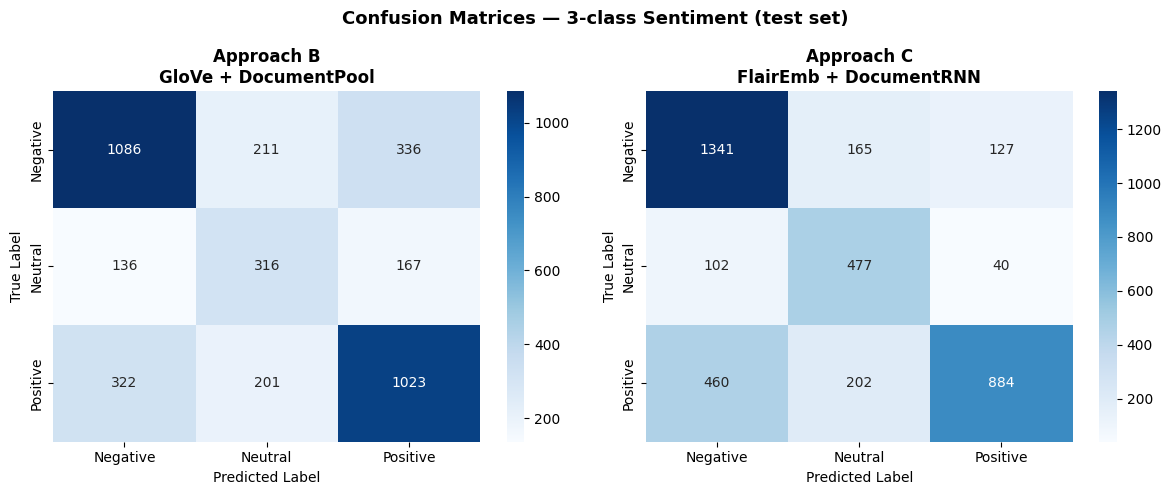

Interpretation: large numbers on the diagonal = good. Off-diagonal = confusion between classes.


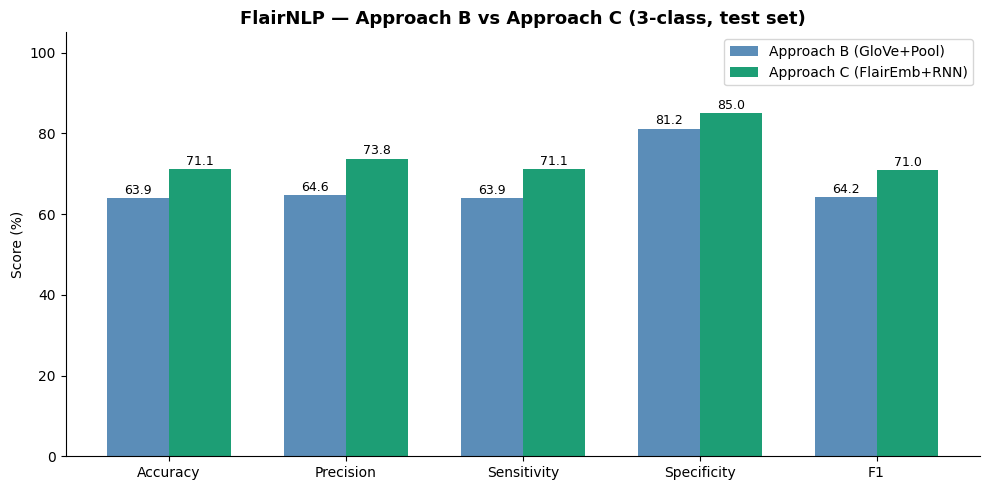

In [32]:
# ── Visualisation 1: Confusion Matrices ───────────────────────────────────────
# A confusion matrix shows WHAT the model is getting wrong, not just HOW MUCH.
# Row = true label, Column = predicted label.
# Diagonal cells = correct predictions (we want these to be large).
# Off-diagonal = mistakes (we want these to be small).

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
class_names_display = ['Negative', 'Neutral', 'Positive']

for ax, preds, title in zip(
    axes,
    [preds_b, preds_c],
    ['Approach B\nGloVe + DocumentPool', 'Approach C\nFlairEmb + DocumentRNN']
):
    cm = confusion_matrix(test_labels_int, preds)

    # sns.heatmap() draws a colour-coded grid of the confusion matrix values
    # annot=True: write the number in each cell
    # fmt='d': format numbers as integers
    # cmap='Blues': colour scheme (darker = higher value)
    sns.heatmap(
        cm,
        annot=True, fmt='d', cmap='Blues',
        xticklabels=class_names_display,
        yticklabels=class_names_display,
        ax=ax
    )
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.suptitle('Confusion Matrices — 3-class Sentiment (test set)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrices.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Interpretation: large numbers on the diagonal = good. Off-diagonal = confusion between classes.")


# ── Visualisation 2: Metric comparison bar chart ──────────────────────────────
metrics_to_plot = ['Accuracy', 'Precision', 'Sensitivity', 'Specificity', 'F1']
x = np.arange(len(metrics_to_plot))   # x positions for the bars
width = 0.35                           # width of each bar

fig, ax = plt.subplots(figsize=(10, 5))

# Two sets of bars side by side — one for each approach
bars_b = ax.bar(x - width/2, [metrics_b[m] for m in metrics_to_plot],
                width, label='Approach B (GloVe+Pool)', color='#5B8DB8')
bars_c = ax.bar(x + width/2, [metrics_c[m] for m in metrics_to_plot],
                width, label='Approach C (FlairEmb+RNN)', color='#1D9E75')

# Add value labels on top of each bar
for bar in list(bars_b) + list(bars_c):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.3,
            f'{h:.1f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot)
ax.set_ylabel('Score (%)')
ax.set_ylim(0, 105)
ax.set_title('FlairNLP — Approach B vs Approach C (3-class, test set)', fontsize=13, fontweight='bold')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'metrics_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

In [33]:
from flair.data import Sentence
from flair.models import TextClassifier
!pip install flair==0.15.1 --quiet # Ensure flair is installed

# ── Live demo: type any tweet and get a prediction ────────────────────────────
# This uses the best Approach C model (FlairEmbeddings — the strongest Flair-native model)

# Load the saved model
best_model = TextClassifier.load(os.path.join(OUTPUT_DIR, 'output_c', 'best-model.pt'))

INT_TO_STR = {2: '✅ POSITIVE', 1: '😐 NEUTRAL', 0: '❌ NEGATIVE'}

def predict_tweet(raw_tweet: str) -> str:
    """
    Preprocess a tweet and predict its sentiment.
    Returns a human-readable string with the label and confidence score.
    """
    # Step 1: clean the tweet exactly like we cleaned the training data
    cleaned = preprocess_tweet(raw_tweet)

    # Step 2: wrap in Sentence, predict, read result
    sentence = Sentence(cleaned)
    best_model.predict(sentence)
    label = sentence.labels[0]

    label_int = STR_TO_INT.get(label.value.lower(), 1)
    label_display = INT_TO_STR[label_int]

    return f"{label_display}  (confidence: {label.score:.1%})"


# Test on new examples that were never in the training data
new_tweets = [
    "covid sucks, but im happy about the",
    "Another lockdown?? This government has no idea what they are doing.",
    "COVID-19 update: 500 new cases reported in the region today.",
    "Social distancing is so lonely. Missing my family terribly.",
    "The healthcare workers are true heroes. Thank you all so much."
]

print("=== Live Sentiment Predictions (Approach C — best Flair model) ===")
print()
for tweet in new_tweets:
    pred = predict_tweet(tweet)
    print(f"Tweet:  {tweet}")
    print(f"Result: {pred}")
    print()

=== Live Sentiment Predictions (Approach C — best Flair model) ===

Tweet:  covid sucks, but im happy about the
Result: ❌ NEGATIVE  (confidence: 42.0%)

Tweet:  Another lockdown?? This government has no idea what they are doing.
Result: ❌ NEGATIVE  (confidence: 96.4%)

Tweet:  COVID-19 update: 500 new cases reported in the region today.
Result: 😐 NEUTRAL  (confidence: 86.3%)

Tweet:  Social distancing is so lonely. Missing my family terribly.
Result: ❌ NEGATIVE  (confidence: 75.4%)

Tweet:  The healthcare workers are true heroes. Thank you all so much.
Result: ✅ POSITIVE  (confidence: 89.5%)



---
## 📋 Summary

### What we built

| Approach | Embeddings | Fine-tuned? | Speed | Strength |
|---|---|---|---|---|
| **A** — Pre-trained Flair | IMDB-trained model | No | Instant | Binary only, ~74% |
| **B** — GloVe + DocumentPool | Static 100d vectors, mean-pooled | Yes | Fast (~5 min) | Good baseline |
| **C** — FlairEmb + DocumentRNN | Char-level 2048d, BiLSTM | Yes | Slow (~30 min) | Best Flair-native |

### Why Approach C is the "proper" FlairNLP approach

- It uses **FlairEmbeddings** — Flair's own unique contribution, not just GloVe or BERT
- Character-level context sensitivity handles the informal, noisy language of tweets
- The BiLSTM captures word order and dependencies like `"not good"` ≠ `"good not"`

### Next steps (for future work)

1. **BERT via Flair** (`TransformerDocumentEmbeddings`) — add BERT as the embedding for best accuracy
2. **5-class classification** — keep all 5 original sentiment labels
3. **More epochs** — run for 20-30 epochs with a learning rate scheduler
4. **Stack GloVe + FlairEmbeddings** — Flair lets you combine multiple embedding types

### GitHub checklist before submission
- [ ] Create repo: `covid-sentiment-analysis`
- [ ] Push this notebook
- [ ] Add a `requirements.txt` file
- [ ] Write a `README.md` explaining what the project does
- [ ] Add supervisor as collaborator: Settings → Collaborators